<a href="https://colab.research.google.com/github/simondiange/simondiange/blob/main/Fruits_and_Vegetables_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
!pip install -q kaggle

In [59]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"ngilladiamond","key":"832e39cf3c8632be3efc7346ec348af7"}'}

In [60]:
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [61]:
! kaggle competitions list

ref                                                                              deadline             category                reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  ---------------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/arc-prize-2025                               2025-11-03 23:59:00  Featured         1,000,000 Usd       1058           False  
https://www.kaggle.com/competitions/jigsaw-agile-community-rules                 2025-10-24 06:59:00  Featured           100,000 Usd       2100           False  
https://www.kaggle.com/competitions/google-code-golf-2025                        2025-10-30 23:59:00  Research           100,000 Usd        877           False  
https://www.kaggle.com/competitions/hull-tactical-market-prediction              2025-12-15 23:59:00  Featured           100,000 Usd        844           False  
https://www.kaggle.com/compe

In [62]:
! kaggle datasets list

ref                                                           title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  -----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
ahmadrazakashif/bmw-worldwide-sales-records-20102024          BMW Worldwide Sales Records (2010–2024)              853348  2025-09-20 14:39:45.280000           4489         93  1.0              
anassarfraz13/student-success-factors-and-insights            Student Success: Factors & Insights                   96178  2025-09-24 07:58:55.117000           2243         48  1.0              
anassarfraz13/coffee-sales-dataset                            Coffee Sales Dataset                                  38970  2025-09-23 09:50:57.187000           1171         22  1.0              
ayeshaimran123/foodpanda-

In [63]:
! kaggle datasets list -s 'fruit-and-vegetable-image-recognition'

ref                                                         title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  -----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
kritikseth/fruit-and-vegetable-image-recognition            Fruits and Vegetables Image Recognition Dataset  2130757290  2022-02-12 06:15:55.417000          52355        464  0.875            
sshikamaru/fruit-recognition                                Fruit Classification                              107089100  2022-06-26 17:20:26.260000          19812        199  0.88235295       
rayhanzamzamy/non-and-biodegradable-waste-dataset           Non and Biodegradable Material Dataset           2000605556  2021-06-12 22:15:41.193000           3998         37  0.875            
alistairking/recyclable-and-househo

In [64]:
! kaggle datasets download -d 'kritikseth/fruit-and-vegetable-image-recognition' -p ../content/fruit-and-vegetable-image-recognition

Dataset URL: https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition
License(s): CC0-1.0
fruit-and-vegetable-image-recognition.zip: Skipping, found more recently modified local copy (use --force to force download)


In [65]:
!ls -ltr ../content/fruit-and-vegetable-image-recognition/

total 2080836
-rwxrwxrwx  1 root root 2130757290 Feb 12  2022 fruit-and-vegetable-image-recognition.zip
drwxrwxrwx 38 root root       4096 Oct  8 06:33 test
drwxrwxrwx 38 root root       4096 Oct  8 06:33 train
drwxrwxrwx 38 root root       4096 Oct  8 06:33 validation


In [66]:
!unzip ../content/fruit-and-vegetable-image-recognition/fruit-and-vegetable-image-recognition.zip -d ../content/fruit-and-vegetable-image-recognition/

Archive:  ../content/fruit-and-vegetable-image-recognition/fruit-and-vegetable-image-recognition.zip
replace ../content/fruit-and-vegetable-image-recognition/test/apple/Image_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [67]:
!chmod 777 -R ../content/fruit-and-vegetable-image-recognition/

In [68]:
!ls -R ../content/fruit-and-vegetable-image-recognition/

../content/fruit-and-vegetable-image-recognition/:
fruit-and-vegetable-image-recognition.zip  test  train	validation

../content/fruit-and-vegetable-image-recognition/test:
 apple	        carrot		 garlic     lettuce   peas	    spinach
 banana         cauliflower	 ginger     mango     pineapple     sweetcorn
 beetroot      'chilli pepper'	 grapes     onion     pomegranate   sweetpotato
'bell pepper'   corn		 jalepeno   orange    potato	    tomato
 cabbage        cucumber	 kiwi	    paprika   raddish	    turnip
 capsicum       eggplant	 lemon	    pear     'soy beans'    watermelon

../content/fruit-and-vegetable-image-recognition/test/apple:
Image_10.jpg  Image_2.jpg  Image_4.jpg	Image_6.JPG  Image_8.jpg
Image_1.jpg   Image_3.jpg  Image_5.jpg	Image_7.jpg  Image_9.jpg

../content/fruit-and-vegetable-image-recognition/test/banana:
Image_10.jpg  Image_2.jpg  Image_4.jpg	Image_6.jpg  Image_9.jpg
Image_1.jpg   Image_3.jpg  Image_5.jpg	Image_8.jpg

../content/fruit-and-vegetable-image-recogniti

In [69]:
import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
import tensorflow as tf
tf.config.list_physical_devices('GPU')
tf.config.set_visible_devices
import warnings
warnings.filterwarnings("ignore")

# Create a list with the filepaths for training and testing
train_dir = Path('/content/fruit-and-vegetable-image-recognition/train')
train_filepaths = list(train_dir.glob(r'**/*.jpg'))

test_dir = Path('/content/fruit-and-vegetable-image-recognition/test')
test_filepaths = list(test_dir.glob(r'**/*.jpg'))

val_dir = Path('/content/fruit-and-vegetable-image-recognition/validation')
val_filepaths = list(test_dir.glob(r'**/*.jpg'))

def proc_img(filepath):
    """ Create a DataFrame with the filepath and the labels of the pictures
    """

    labels = [str(filepath[i]).split("/")[-2] \
              for i in range(len(filepath))]

    filepath = pd.Series(filepath, name='Filepath').astype(str)
    labels = pd.Series(labels, name='Label')

    # Concatenate filepaths and labels
    df = pd.concat([filepath, labels], axis=1)

    # Shuffle the DataFrame and reset index
    df = df.sample(frac=1).reset_index(drop = True)

    return df

train_df = proc_img(train_filepaths)
test_df = proc_img(test_filepaths)
val_df = proc_img(val_filepaths)

In [70]:
print('-- Training set --\n')
print(f'Number of pictures: {train_df.shape[0]}\n')
print(f'Number of different labels: {len(train_df.Label.unique())}\n')
print(f'Labels: {train_df.Label.unique()}')

-- Training set --

Number of pictures: 2780

Number of different labels: 36

Labels: ['cabbage' 'jalepeno' 'beetroot' 'spinach' 'kiwi' 'cauliflower'
 'bell pepper' 'potato' 'pomegranate' 'tomato' 'soy beans' 'garlic'
 'turnip' 'apple' 'lemon' 'sweetpotato' 'cucumber' 'sweetcorn' 'mango'
 'paprika' 'raddish' 'carrot' 'peas' 'pear' 'eggplant' 'lettuce'
 'pineapple' 'capsicum' 'onion' 'banana' 'watermelon' 'corn'
 'chilli pepper' 'grapes' 'orange' 'ginger']


In [71]:
# The DataFrame with the filepaths in one column and the labels in the other one
train_df.head(5)

,Filepath,Label
0,/content/fruit-and-vegetable-image-recognition...,cabbage
1,/content/fruit-and-vegetable-image-recognition...,cabbage
2,/content/fruit-and-vegetable-image-recognition...,jalepeno
3,/content/fruit-and-vegetable-image-recognition...,beetroot
4,/content/fruit-and-vegetable-image-recognition...,spinach


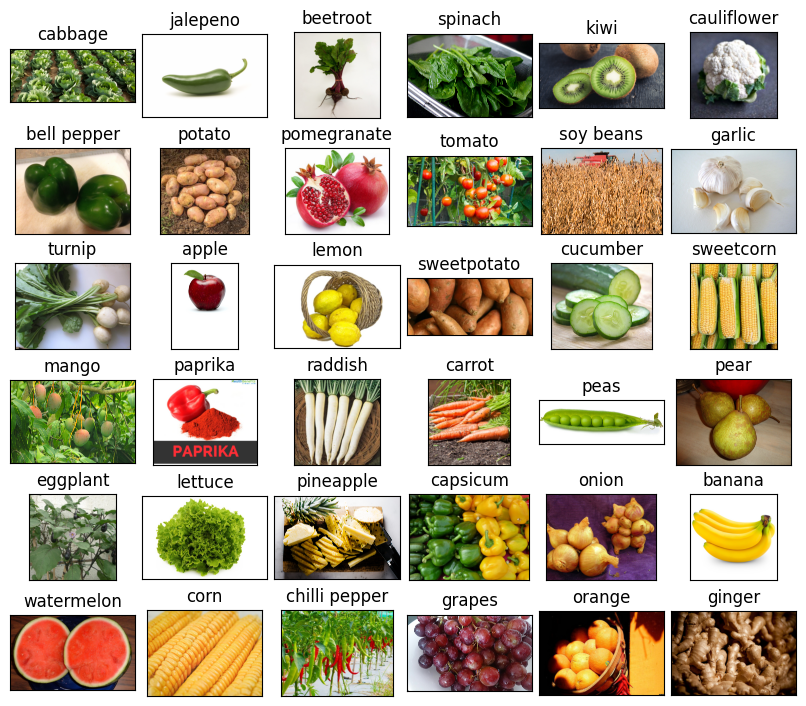

In [72]:
# Create a DataFrame with one Label of each category
df_unique = train_df.copy().drop_duplicates(subset=["Label"]).reset_index()

# Display some pictures of the dataset
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(8, 7),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(df_unique.Filepath[i]))
    ax.set_title(df_unique.Label[i], fontsize = 12)
plt.tight_layout(pad=0.5)
plt.show()

**# 2 Load the images with a generator and Data Augumentation**

In [73]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=0,
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_images = train_generator.flow_from_dataframe(
    dataframe=val_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=0,
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 2780 validated image filenames belonging to 36 classes.
Found 334 validated image filenames belonging to 36 classes.
Found 334 validated image filenames belonging to 36 classes.


In [74]:
# Load the pretained model
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
pretrained_model.trainable = False

**# 3 Train the Model**

In [76]:
inputs = pretrained_model.input

x = tf.keras.layers.Dense(128, activation='relu')(pretrained_model.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)

outputs = tf.keras.layers.Dense(36, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    validation_data=val_images,
    batch_size = 32,
    epochs=5,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True
        )
    ]
)

Epoch 1/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.3597 - loss: 2.5251 - val_accuracy: 0.8982 - val_loss: 0.4419
Epoch 2/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.8126 - loss: 0.5951 - val_accuracy: 0.9222 - val_loss: 0.3102
Epoch 3/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.8983 - loss: 0.3297 - val_accuracy: 0.9192 - val_loss: 0.2437
Epoch 4/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.9455 - loss: 0.1962 - val_accuracy: 0.9371 - val_loss: 0.2079
Epoch 5/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.9590 - loss: 0.1476 - val_accuracy: 0.9551 - val_loss: 0.1761


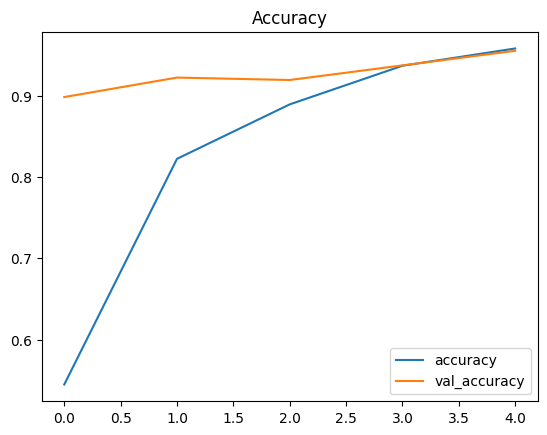

In [77]:
pd.DataFrame(history.history)[['accuracy','val_accuracy']].plot()
plt.title("Accuracy")
plt.show()

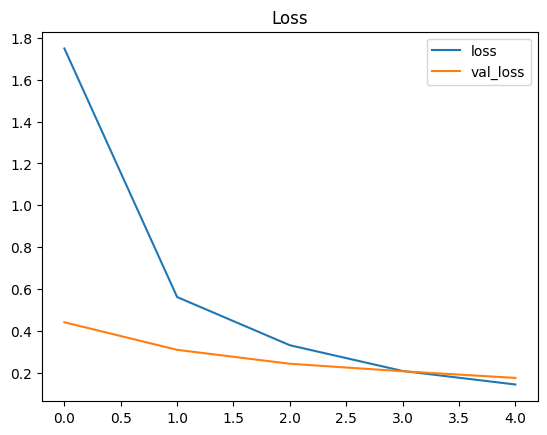

In [78]:
pd.DataFrame(history.history)[['loss','val_loss']].plot()
plt.title("Loss")
plt.show()

**# 4 Visualize the result**

In [79]:
labels.items()

dict_items([(0, 'apple'), (1, 'banana'), (2, 'beetroot'), (3, 'bell pepper'), (4, 'cabbage'), (5, 'capsicum'), (6, 'carrot'), (7, 'cauliflower'), (8, 'chilli pepper'), (9, 'corn'), (10, 'cucumber'), (11, 'eggplant'), (12, 'garlic'), (13, 'ginger'), (14, 'grapes'), (15, 'jalepeno'), (16, 'kiwi'), (17, 'lemon'), (18, 'lettuce'), (19, 'mango'), (20, 'onion'), (21, 'orange'), (22, 'paprika'), (23, 'pear'), (24, 'peas'), (25, 'pineapple'), (26, 'pomegranate'), (27, 'potato'), (28, 'raddish'), (29, 'soy beans'), (30, 'spinach'), (31, 'sweetcorn'), (32, 'sweetpotato'), (33, 'tomato'), (34, 'turnip'), (35, 'watermelon')])

In [80]:
# Predict the label of the test_images
pred = model.predict(test_images)
pred = np.argmax(pred,axis=1)

# Map the label
labels = (train_images.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred = [labels[k] for k in pred]

y_test = [labels[k] for k in test_images.classes]

11/11 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step


In [ ]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, pred)
print(f'Accuracy on the test set: {100*acc:.2f}%')

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cf_matrix = confusion_matrix(y_test, pred, normalize='true')
plt.figure(figsize = (10,5))
sns.heatmap(cf_matrix,
            annot=True,
            xticklabels = sorted(set(y_test)),
            yticklabels = sorted(set(y_test)),
            )
plt.title('Normalized Confusion Matrix')
plt.show()

In [ ]:
# Display some pictures of the dataset with their labels and the predictions
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(5, 5),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(test_df.Filepath.iloc[i]))
    ax.set_title(f"True: {test_df.Label.iloc[i]}\nPredicted: {pred[i]}")
plt.tight_layout()
plt.show()

## 5. Class activation heatmap for image classification<a class="anchor" id="5"></a>
### Grad-CAM class activation visualization
*Code adapted from keras.io*

In [ ]:
import matplotlib.cm as cm

def get_img_array(img_path, size):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    array = tf.keras.preprocessing.image.img_to_array(img)
    # We add a dimension to transform our array into a "batch"
    # of size "size"
    array = np.expand_dims(array, axis=0)
    return array

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def save_and_display_gradcam(img_path, heatmap, cam_path="cam.jpg", alpha=0.4):
    # Load the original image
    img = tf.keras.preprocessing.image.load_img(img_path)
    img = tf.keras.preprocessing.image.img_to_array(img)

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    # Save the superimposed image
    superimposed_img.save(cam_path)

    # Display Grad CAM
#     display(Image(cam_path))

    return cam_path

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
decode_predictions = tf.keras.applications.mobilenet_v2.decode_predictions

last_conv_layer_name = "Conv_1"
img_size = (224,224)

# Remove last layer's softmax
model.layers[-1].ativation = None

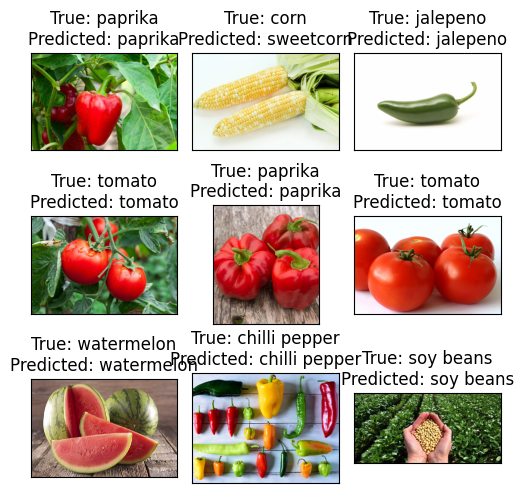

In [85]:
# Display some pictures of the dataset with their labels and the predictions
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(5, 5),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(test_df.Filepath.iloc[i]))
    ax.set_title(f"True: {test_df.Label.iloc[i]}\nPredicted: {pred[i]}")
plt.tight_layout()
plt.show()

In [86]:
model.save('FruitandVegetableModel.h5')

In [87]:
from google.colab import files

# Download the saved model
files.download('FruitandVegetableModel.h5')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>